# C10 · Code walkthrough: `controls/` (static stability, trim, tail sizing)

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). The numbers in this notebook are computed on the sized Halo (`baseline()`, rebuilt with
`build_halo_aircraft`), except where the `tail_sizing.py` example is run.

| Module | Lines | What it holds |
|---|---|---|
| `controls/__init__.py` | 1 | the package docstring only |
| `controls/stability.py` | 143 | `flap_effectiveness`, `LongitudinalStability` (neutral point, static margin, pitch moment and trim drag), `DirectionalStability` (Cn_beta, rudder), `failed_propulsor_yaw_moment_Nm` |
| `examples/tail_sizing.py` | 143 | the plan 007 reference problem: wing position and both tail areas inside the mass closure |
| `examples/halo_sizing.py` (excerpts) | 1083-1084, 1255-1272, 1299-1302 | where the Halo sizing uses `static_margin` and `cn_beta_per_rad`, and the hover CG equality |

**What `stability.py` imports:** `aerosandbox` (atmosphere, CasADi-aware numpy), `oswalds_efficiency` from the
AeroSandbox inviscid library, and `DragIncrement` from `aerodynamics/simple.py`. It never imports an aerodynamics
*model*: the model is passed in (duck typing) and must provide `lift_curve_slope_per_rad`,
`surface_lift_curve_slope_per_rad` and `evaluate(...).cl`.

**Who imports it (grep):** `examples/halo_sizing.py` (L49: SM and Cn_beta margins), `examples/coupled_sizing.py`
(L32), `examples/tail_sizing.py` (L22), `trajectory/corridor.py` (L46: `flap_effectiveness`; `build_trim` calls
`LongitudinalStability.evaluate`), `examples/halo_conversion_corridor.py` (L16), and the tests
`tests/controls/test_stability.py`, `tests/trajectory/test_corridor.py`, `tests/integration/test_tail_sizing.py`.

Design log: `docs/decisions/007-stability-trim-tail-sizing.md` (Tier 6). The Halo constraints are in
`docs/decisions/013-halo-class-sizing.md` (SM >= 0.10 and Cn_beta >= 0.06/rad size the tails).

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
from types import SimpleNamespace
from examples.halo_sizing import HaloRequirements, build_halo_aerodynamics, build_halo_aircraft
from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.controls.stability import (DirectionalStability, LongitudinalStability, flap_effectiveness,
                                                 failed_propulsor_yaw_moment_Nm, _quarter_mac_x_m)
from aircraft_closure.performance.flight_point import acceleration_gravity_m_s2

ref = baseline()
requirements, assumptions = HaloRequirements(), baseline_assumptions()
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
aero = build_halo_aerodynamics(requirements, assumptions)            # BuildupAerodynamics (the default model)
simple = SimpleAerodynamics()
longitudinal, directional = LongitudinalStability(), DirectionalStability()
V, h = 80.0, 1000.0                                                  # the sizing's stability point
x_cg_m = aircraft.wing.x_le_root_m + 0.25 * aircraft.wing.chord_root_m()   # what the hover equality enforces
f = scalar
print(type(aero).__name__, "| wing", f(aircraft.wing.area_m2), "m2, AR", aircraft.wing.aspect_ratio,
      "| HT", round(f(aircraft.horizontal_tail.area_m2), 3), "m2 at x_le", aircraft.horizontal_tail.x_le_root_m,
      "| VT", round(f(aircraft.vertical_tail.area_m2), 3), "m2 | x_cg", round(x_cg_m, 4), "m")

BuildupAerodynamics | wing 23.29867496825564 m2, AR 6.12 | HT 5.246 m2 at x_le 9.8 | VT 2.732 m2 | x_cg 5.1113 m


---
## 1. `controls/stability.py`: header, flap effectiveness, helpers

In [2]:
show_source("src/aircraft_closure/controls/stability.py", 1, 36)

# src/aircraft_closure/controls/stability.py  lines 1-36
   1  """Static stability, pitch trim and rudder authority for a conventional tail.
   2  
   3  Equations only: callers own trim variables (alpha, elevator) and constraints
   4  (Cm = 0, lift = weight, margins). Surfaces are unswept, so aerodynamic centres
   5  sit at the quarter MAC. Angles are degrees at the interface, radians inside.
   6  References: Raymer ch. 16 (fuselage pitch and yaw terms); classical
   7  neutral-point and downwash relations (Etkin and Reid, Nelson); thin-airfoil
   8  flap effectiveness.
   9  """
  10  from dataclasses import dataclass
  11  from typing import Any
  12  
  13  import aerosandbox as asb
  14  import aerosandbox.numpy as np
  15  from aerosandbox.library.aerodynamics.inviscid import oswalds_efficiency
  16  
  17  from aircraft_closure.aerodynamics.simple import DragIncrement
  18  
  19  
  20  def flap_effectiveness(chord_fraction, correction=0.8):
  21      """Thin-airfoil d(alpha

**Line by line**

- **L1-9 docstring, the contract.** "Equations only": no `opti.variable`, no `subject_to`, no solve inside this
  module. The caller owns alpha, the elevator and every constraint (Cm = 0, lift = weight, SM >= 0.10). This is the
  rule of decision 007 ("no hidden solve in controls code"). Two simplifications are stated here: surfaces are
  unswept, so each aerodynamic centre is the quarter MAC; angles are degrees at the interface and radians inside.
- **L13-17 imports.** `aerosandbox.numpy` dispatches to NumPy or CasADi, so every function accepts floats or Opti
  expressions. `DragIncrement` is the Tier 5 hook through which trim drag enters a drag polar.
- **L20-27 `flap_effectiveness`.** Thin-airfoil change of zero-lift angle per unit flap deflection for a plain flap
  of chord fraction c_f/c:

$$\theta = \arccos(2\,c_f/c - 1), \qquad \tau = k\left[1 - \frac{\theta - \sin\theta}{\pi}\right]$$

  with k = `correction` = 0.8 (a stated viscous loss, not calibrated: decision 007, "Progress and decisions").
  tau(0) = 0 and tau(1) = 1 before the correction. The function is smooth on the open interval and symbolic-safe.
- **L30-31 `_quarter_mac_x_m`.** x of the aerodynamic centre = root leading edge + 0.25 MAC. Correct only because the
  leading edges are unswept (`vehicle/surfaces.py`: both sections at the same `x_le_root_m`), so the MAC leading
  edge is at the root leading edge for any taper. It builds an `asb.Wing` (`to_asb()`) just to read the MAC.
- **L34-35 `_dynamic_pressure_Pa`.** q = 0.5 rho V^2 with the ISA density at `altitude_m`. No temperature offset:
  stability is always evaluated on a standard day.

**Run it**

In [3]:
for c in (0.0, 0.2, 0.3, 0.4, 1.0):
    print(f"c_f/c = {c:.1f}: tau = {f(flap_effectiveness(c)):.4f}  (thin airfoil only: {f(flap_effectiveness(c, 1.0)):.4f})")
check("tau(0) = 0 and tau(1) = 1 without correction",
      abs(f(flap_effectiveness(0.0, 1.0))) < 1e-12 and abs(f(flap_effectiveness(1.0, 1.0)) - 1) < 1e-12)
tail = aircraft.horizontal_tail
print("elevator chord fraction", tail.elevator_chord_fraction, "-> tau_e =", round(f(flap_effectiveness(tail.elevator_chord_fraction)), 4))
mac_wing = f(aircraft.wing.to_asb().mean_aerodynamic_chord())
print(f"wing MAC {mac_wing:.4f} m = root chord {f(aircraft.wing.chord_root_m()):.4f} m (taper 1)")
print(f"wing ac x = {f(_quarter_mac_x_m(aircraft.wing)):.4f} m, tail ac x = {f(_quarter_mac_x_m(tail)):.4f} m")
check("rectangular wing: quarter MAC == quarter root chord == hover CG",
      abs(f(_quarter_mac_x_m(aircraft.wing)) - x_cg_m) < 1e-12)
opti = asb.Opti(); c_f = opti.variable(init_guess=0.3)
print("symbolic:", type(flap_effectiveness(c_f)).__name__)

c_f/c = 0.0: tau = 0.0000  (thin airfoil only: 0.0000)
c_f/c = 0.2: tau = 0.4399  (thin airfoil only: 0.5498)
c_f/c = 0.3: tau = 0.5286  (thin airfoil only: 0.6607)
c_f/c = 0.4: tau = 0.5982  (thin airfoil only: 0.7478)
c_f/c = 1.0: tau = 0.8000  (thin airfoil only: 1.0000)
PASS  tau(0) = 0 and tau(1) = 1 without correction
elevator chord fraction 0.3 -> tau_e = 0.5286
wing MAC 1.9511 m = root chord 1.9511 m (taper 1)
wing ac x = 5.1113 m, tail ac x = 10.1167 m
PASS  rectangular wing: quarter MAC == quarter root chord == hover CG
symbolic: MX


---
## 2. `LongitudinalStability`: terms, lift slope, neutral point, static margin

In [4]:
show_source("src/aircraft_closure/controls/stability.py", 37, 86)

# src/aircraft_closure/controls/stability.py  lines 37-86
  37  
  38  @dataclass(frozen=True)
  39  class LongitudinalResult:
  40      cl_total: Any
  41      cl_wing: Any
  42      cl_tail: Any
  43      cm: Any
  44      downwash_deg: Any
  45      lift_N: Any
  46      trim_drag: Any
  47  
  48  
  49  @dataclass(frozen=True)
  50  class LongitudinalStability:
  51      tail_dynamic_pressure_ratio: Any = 0.9
  52      cm_ac_wing: Any = -0.09
  53      fuselage_pitch_factor_per_deg: Any = 0.012
  54      tail_incidence_deg: Any = 0.0
  55      flap_effectiveness_correction: Any = 0.8
  56  
  57      def _terms(self, aircraft, aerodynamics, velocity_m_s, altitude_m):
  58          wing, tail, fuselage = aircraft.wing, aircraft.horizontal_tail, aircraft.fuselage
  59          chord_m = wing.to_asb().mean_aerodynamic_chord()
  60          slope_wing = aerodynamics.lift_curve_slope_per_rad(aircraft, velocity_m_s, altitude_m)
  61          slope_tail = aerodynamics.surface_lift_curve_

**Line by line**

- **L38-46 `LongitudinalResult`.** A frozen container of expressions: total, wing and tail lift coefficients, the
  pitching moment coefficient about the CG, the downwash (deg), the lift force (N) and the tail induced drag as a
  `DragIncrement`. Fields are `Any`: floats or CasADi.
- **L49-55 the assumptions**, all dataclass fields so a caller can vary them (or even make them Opti variables):
  tail dynamic pressure ratio eta_H = 0.9, wing Cm_ac = -0.09 (cambered section, nose down), the Raymer fuselage
  factor K_fus = 0.012 per degree, tail incidence i_H = 0 deg, flap correction 0.8.
- **L57-67 `_terms`**, the shared building blocks:
  - L59 the reference chord is the wing MAC (`c`);
  - L60-61 the slopes come from the aerodynamics model: `lift_curve_slope_per_rad` (wing) and
    `surface_lift_curve_slope_per_rad(AR_tail)`. For both `SimpleAerodynamics` and `BuildupAerodynamics` these are the
    analytic isolated-surface slopes 2 pi CL_over_Cl(AR, M) (`buildup.py` L106-113). **So the neutral point and the
    static margin never call AeroBuildup**; they are analytic even when AeroBuildup is the aero model;
  - L62 downwash gradient of an elliptic wing, d eps / d alpha = 2 a_w / (pi AR);
  - L63 `tail_volume_ratio` is eta_H S_H / S. The name is misleading: it has no arm, it is an *area* ratio times eta;
  - L64-66 Raymer eq. 16.25 fuselage term, positive (destabilizing), converted from per degree to per radian:

$$C_{m\alpha,fus} = \frac{K_{fus}\, W_f^2\, L_f}{c\, S}\cdot\frac{180}{\pi}$$

- **L69-72 `lift_curve_slope_total_per_rad`:** a_tot = a_w + eta_H (S_H/S) a_H (1 - d eps/d alpha). The tail adds
  lift slope, reduced by downwash.
- **L74-81 `neutral_point_x_m`:** the lift-slope-weighted average of the two aerodynamic centres, shifted forward by
  the fuselage:

$$x_{np} = \frac{a_w\,x_{ac,w} + a_{t,eff}\,x_{ac,t}}{a_{tot}} - \frac{C_{m\alpha,fus}\,c}{a_{tot}}, \qquad a_{t,eff} = \eta_H \frac{S_H}{S} a_H \left(1 - \frac{d\varepsilon}{d\alpha}\right)$$

  This is the x where Cm_alpha about the CG would vanish (decision 007, "Physics"). No Cm_ac term: a constant moment
  does not change with alpha.
- **L83-85 `static_margin`:** SM = (x_np - x_cg) / c, positive = stable. The function recomputes the MAC (L84) and
  `_terms` (via L85): cheap numerically, a few duplicate graph nodes symbolically.

**Run it on the sized Halo.** Reproduce the sizing's two numbers and break the neutral point into its parts.

In [5]:
chord_m, slope_w, slope_t, deps, vol_ratio, cm_fus = (f(x) for x in longitudinal._terms(aircraft, aero, V, h))
slope_tot = f(longitudinal.lift_curve_slope_total_per_rad(aircraft, aero, V, h))
x_np = f(longitudinal.neutral_point_x_m(aircraft, aero, V, h))
sm = f(longitudinal.static_margin(aircraft, aero, x_cg_m, V, h))
cnb = f(directional.cn_beta_per_rad(aircraft, aero, x_cg_m, V, h))
x_ac_w, x_ac_t = f(_quarter_mac_x_m(aircraft.wing)), f(_quarter_mac_x_m(aircraft.horizontal_tail))
slope_t_eff = vol_ratio * slope_t * (1 - deps)
print(f"MAC c = {chord_m:.4f} m | a_w = {slope_w:.4f} /rad | a_H = {slope_t:.4f} /rad | d eps/d alpha = {deps:.4f}")
print(f"eta S_H/S = {vol_ratio:.4f} | a_t,eff = {slope_t_eff:.4f} /rad | a_tot = {slope_tot:.4f} /rad | Cm_alpha,fus = {cm_fus:+.4f} /rad")
print(f"x_ac,w = {x_ac_w:.4f} m | x_ac,t = {x_ac_t:.4f} m")
print(f"  weighted ac       = {(slope_w * x_ac_w + slope_t_eff * x_ac_t) / slope_tot:.4f} m")
print(f"  fuselage shift    = {-cm_fus * chord_m / slope_tot:+.4f} m")
print(f"  neutral point     = {x_np:.4f} m   (CG {x_cg_m:.4f} m, {x_np - x_cg_m:.4f} m aft of it)")
print(f"static margin {sm:.6f} (sizing result {ref.static_margin:.6f}) | Cn_beta {cnb:.6f} /rad (sizing {ref.cn_beta_per_rad:.6f})")
check("static_margin on the rebuilt aircraft reproduces baseline().static_margin", abs(sm - ref.static_margin) < 1e-6)
check("cn_beta_per_rad reproduces baseline().cn_beta_per_rad", abs(cnb - ref.cn_beta_per_rad) < 1e-6)
check("both stability constraints are binding at the baseline (0.10 and 0.06/rad)",
      abs(ref.static_margin - 0.10) < 1e-4 and abs(ref.cn_beta_per_rad - 0.06) < 1e-4)
check("SM = (x_np - x_cg)/MAC", abs(sm - (x_np - x_cg_m) / chord_m) < 1e-12)
check("CG at the neutral point gives SM = 0", abs(f(longitudinal.static_margin(aircraft, aero, x_np, V, h))) < 1e-12)
check("neutral point identical with SimpleAerodynamics (only the analytic slopes are used)",
      abs(f(longitudinal.neutral_point_x_m(aircraft, simple, V, h)) - x_np) < 1e-12)

MAC c = 1.9511 m | a_w = 4.5162 /rad | a_H = 3.4698 /rad | d eps/d alpha = 0.4698
eta S_H/S = 0.2027 | a_t,eff = 0.3728 /rad | a_tot = 4.8891 /rad | Cm_alpha,fus = +0.4676 /rad
x_ac,w = 5.1113 m | x_ac,t = 10.1167 m
  weighted ac       = 5.4930 m
  fuselage shift    = -0.1866 m
  neutral point     = 5.3064 m   (CG 5.1113 m, 0.1951 m aft of it)
static margin 0.100000 (sizing result 0.100000) | Cn_beta 0.060000 /rad (sizing 0.060000)
PASS  static_margin on the rebuilt aircraft reproduces baseline().static_margin
PASS  cn_beta_per_rad reproduces baseline().cn_beta_per_rad
PASS  both stability constraints are binding at the baseline (0.10 and 0.06/rad)
PASS  SM = (x_np - x_cg)/MAC
PASS  CG at the neutral point gives SM = 0
PASS  neutral point identical with SimpleAerodynamics (only the analytic slopes are used)


**Cm_alpha = -SM CL_alpha,tot by finite difference.** Differentiate the moment of `evaluate` (section 3) with
respect to alpha, about the hover CG and about a CG 0.3 m forward (so the wing lift term is not zero). Do it with
`SimpleAerodynamics`, whose `evaluate(...).cl` is the analytic wing lift, and with `BuildupAerodynamics`, the Halo's
model. The identity is exact only when `evaluate`'s wing lift slope equals the a_w of the neutral point.

In [6]:
def cm_of(model, x_cg, alpha_deg, elevator_deg=0.0):
    return f(longitudinal.evaluate(aircraft, model, x_cg, V, h, alpha_deg, elevator_deg).cm)

step_deg = 0.01
rows = {}
for name, model in (("simple", simple), ("buildup", aero)):
    for x_cg in (x_cg_m, x_cg_m - 0.3):
        cm_alpha_fd = (cm_of(model, x_cg, 3 + step_deg) - cm_of(model, x_cg, 3 - step_deg)) / np.radians(2 * step_deg)
        predicted = -f(longitudinal.static_margin(aircraft, model, x_cg, V, h)) * slope_tot
        rows[name, round(x_cg - x_cg_m, 1)] = (cm_alpha_fd, predicted)
        print(f"{name:<8} CG {x_cg - x_cg_m:+.1f} m: Cm_alpha FD = {cm_alpha_fd:+.5f} /rad, -SM a_tot = {predicted:+.5f} /rad")
check("Cm_alpha = -SM * CL_alpha_total (SimpleAerodynamics, hover CG)", abs(np.subtract(*rows["simple", 0.0])) < 1e-6)
check("Cm_alpha = -SM * CL_alpha_total (SimpleAerodynamics, CG 0.3 m forward)", abs(np.subtract(*rows["simple", -0.3])) < 1e-6)
check("with BuildupAerodynamics the identity does NOT hold (evaluate's lift slope != a_w)",
      abs(np.subtract(*rows["buildup", 0.0])) > 0.05)

simple   CG +0.0 m: Cm_alpha FD = -0.48891 /rad, -SM a_tot = -0.48891 /rad
simple   CG -0.3 m: Cm_alpha FD = -1.24063 /rad, -SM a_tot = -1.24063 /rad


buildup  CG +0.0 m: Cm_alpha FD = -0.29655 /rad, -SM a_tot = -0.48891 /rad
buildup  CG -0.3 m: Cm_alpha FD = -1.19435 /rad, -SM a_tot = -1.24063 /rad
PASS  Cm_alpha = -SM * CL_alpha_total (SimpleAerodynamics, hover CG)
PASS  Cm_alpha = -SM * CL_alpha_total (SimpleAerodynamics, CG 0.3 m forward)
PASS  with BuildupAerodynamics the identity does NOT hold (evaluate's lift slope != a_w)


The identity holds to machine precision with `SimpleAerodynamics` (the test `test_cm_alpha_equals_minus_static_margin_times_lift_slope`
checks the same thing on the small reference aircraft). With the Buildup model it fails: section 3 explains why.

**Is SM independent of the wing position when the CG is tied to the quarter chord?** With x_cg = x_ac,w, the wing
lift term drops out:

$$SM = \frac{x_{np} - x_{ac,w}}{c} = \frac{a_{t,eff}\,(x_{ac,t} - x_{ac,w}) - C_{m\alpha,fus}\,c}{a_{tot}\,c}$$

The wing's own contribution cancels, but the tail arm l_t = x_ac,t - x_ac,w remains, and the Halo tail sits at a
fixed x (`HaloAssumptions.x_horizontal_tail_m` = 9.8 m, `halo_sizing.py` L217, used at L880). So SM *does* depend on
the wing position, through the tail arm, with slope

$$\frac{\partial SM}{\partial x_{le}} = -\frac{a_{t,eff}}{a_{tot}\,c}$$

Shift the wing and recompute (geometry only; the CG follows the quarter chord as the hover equality forces):

wing shift -0.6 m: SM = 0.1235, Cn_beta = 0.0794 /rad
wing shift -0.4 m: SM = 0.1156, Cn_beta = 0.0729 /rad
wing shift -0.2 m: SM = 0.1078, Cn_beta = 0.0665 /rad
wing shift +0.0 m: SM = 0.1000, Cn_beta = 0.0600 /rad
wing shift +0.2 m: SM = 0.0922, Cn_beta = 0.0535 /rad
wing shift +0.4 m: SM = 0.0844, Cn_beta = 0.0471 /rad
wing shift +0.6 m: SM = 0.0765, Cn_beta = 0.0406 /rad
dSM/dx_le: fit -0.03908 /m, analytic -a_t,eff/(a_tot c) = -0.03908 /m
PASS  SM is NOT independent of wing position (tail at fixed x): it changes by > 0.03 over +/-0.6 m
PASS  dSM/dx_le matches -a_t,eff/(a_tot c) (SM is linear in the shift)
PASS  with x_cg = x_ac,w, SM = [a_t,eff l_t - Cm_alpha,fus c]/(a_tot c)


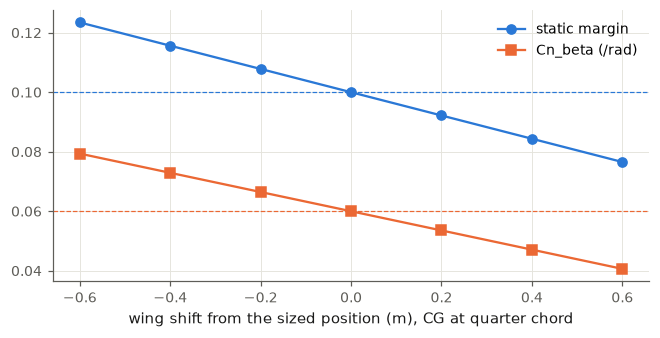

In [7]:
shifts_m = np.linspace(-0.6, 0.6, 7)
sm_shift, cnb_shift = [], []
for dx in shifts_m:
    moved = build_halo_aircraft(replace(ref.design, x_le_wing_m=ref.design.x_le_wing_m + dx), requirements, assumptions)
    x_cg_moved = moved.wing.x_le_root_m + 0.25 * moved.wing.chord_root_m()
    sm_shift.append(f(longitudinal.static_margin(moved, aero, x_cg_moved, V, h)))
    cnb_shift.append(f(directional.cn_beta_per_rad(moved, aero, x_cg_moved, V, h)))
for dx, s, c in zip(shifts_m, sm_shift, cnb_shift):
    print(f"wing shift {dx:+.1f} m: SM = {s:.4f}, Cn_beta = {c:.4f} /rad")
slope_fd = np.polyfit(shifts_m, sm_shift, 1)[0]
slope_analytic = -slope_t_eff / (slope_tot * chord_m)
print(f"dSM/dx_le: fit {slope_fd:.5f} /m, analytic -a_t,eff/(a_tot c) = {slope_analytic:.5f} /m")
check("SM is NOT independent of wing position (tail at fixed x): it changes by > 0.03 over +/-0.6 m",
      max(sm_shift) - min(sm_shift) > 0.03)
check("dSM/dx_le matches -a_t,eff/(a_tot c) (SM is linear in the shift)",
      abs(slope_fd - slope_analytic) < 1e-6 and np.ptp(np.diff(sm_shift)) < 1e-9)
sm_formula = (slope_t_eff * (x_ac_t - x_ac_w) - cm_fus * chord_m) / (slope_tot * chord_m)
check("with x_cg = x_ac,w, SM = [a_t,eff l_t - Cm_alpha,fus c]/(a_tot c)", abs(sm_formula - sm) < 1e-12)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(shifts_m, sm_shift, color=blue, marker="o", label="static margin")
ax.plot(shifts_m, cnb_shift, color=orange, marker="s", label="Cn_beta (/rad)")
ax.axhline(0.10, color=blue, lw=0.8, ls="--"); ax.axhline(0.06, color=orange, lw=0.8, ls="--")
ax.set_xlabel("wing shift from the sized position (m), CG at quarter chord"); ax.legend(); plt.show()

The correct statement is narrower: **with the CG tied to the wing quarter chord, SM no longer depends on where the CG
sits relative to the wing** (the wing term vanishes); it becomes a tail-volume condition on S_H times the arm
l_t, plus the fixed fuselage term. Moving the wing aft shortens both tail arms, so SM and Cn_beta fall together. In the
sizing the optimizer trades wing position against S_H and S_V under these two binding constraints and the mass
closure. ("SM is independent of wing position" would hold only if the tail moved with the wing.)

---
## 3. `LongitudinalStability.evaluate`: moment, trimmed lift, trim drag

In [8]:
show_source("src/aircraft_closure/controls/stability.py", 87, 110)

# src/aircraft_closure/controls/stability.py  lines 87-110
  87      def evaluate(self, aircraft, aerodynamics, x_cg_m, velocity_m_s, altitude_m, alpha_deg, elevator_deg):
  88          chord_m, _, slope_tail, _, tail_volume_ratio, cm_alpha_fuselage = self._terms(
  89              aircraft, aerodynamics, velocity_m_s, altitude_m)
  90          tail = aircraft.horizontal_tail
  91          cl_wing = aerodynamics.evaluate(aircraft, velocity_m_s, altitude_m, alpha_deg).cl
  92          downwash_rad = 2 * cl_wing / (np.pi * aircraft.wing.aspect_ratio)
  93          tau_elevator = flap_effectiveness(tail.elevator_chord_fraction, self.flap_effectiveness_correction)
  94          alpha_tail_rad = (np.radians(alpha_deg + self.tail_incidence_deg) - downwash_rad
  95                            + tau_elevator * np.radians(elevator_deg))
  96          cl_tail = slope_tail * alpha_tail_rad
  97          x_ac_wing_m = _quarter_mac_x_m(aircraft.wing)
  98          x_ac_tail_m = _quarter_mac_x_m(tail

**Line by line**

- **L88-89** reuse `_terms` for the chord, the tail slope a_H, eta S_H/S and the fuselage term.
- **L91 `cl_wing = aerodynamics.evaluate(...).cl`.** The "wing" lift coefficient is whatever the aero model returns.
  For `SimpleAerodynamics` that is a_w (alpha - alpha_0) (`simple.py` L129-130), wing only. For
  `BuildupAerodynamics` it is AeroBuildup's **whole-aircraft** CL (`buildup.py` L162 `cl = out["CL"]`), which already
  contains the horizontal tail at free-stream alpha (no downwash) and the bodies (`buildup.py` L23-25 docstring).
- **L92** downwash eps = 2 CL_w / (pi AR), the elliptic-wing relation evaluated with the L91 lift.
- **L93-96** tail angle of attack and lift, on the tail's own area:

$$\alpha_t = \alpha + i_H - \varepsilon + \tau_e\,\delta_e, \qquad C_{L,t} = a_H\,\alpha_t$$

- **L97-101** moment coefficient about the CG, positive nose up, on S and c:

$$C_m = C_{m,ac,w} + C_{L,w}\frac{x_{cg} - x_{ac,w}}{c} - \eta_H\frac{S_H}{S}C_{L,t}\frac{x_{ac,t} - x_{cg}}{c} + C_{m\alpha,fus}\,\alpha$$

  The fuselage term is linear in absolute alpha (no fuselage zero-moment angle). The tail has no Cm_ac (symmetric).
- **L102** total lift on S: CL = CL_w + eta_H (S_H/S) CL_t. **L108** lift force q S CL.
- **L103-105** trim drag: the tail's induced drag on S, eta (S_H/S) CL_t^2 / (pi e_t AR_t), with the AeroSandbox
  Oswald estimate for the tail's taper and AR. It is a `DragIncrement` so `tail_sizing.py` can feed it to the
  polar (L89-90 there).
- **L106-109** pack the expressions. Nothing is constrained here.

**The tail-lift double count with `BuildupAerodynamics`.** L91 takes AeroBuildup's whole-aircraft CL as the wing
lift, and L102 adds the analytic tail lift on top. The horizontal tail is therefore counted twice in `cl_total`
and `lift_N`, and it also inflates the L92 downwash and the L99 wing moment term. Quantify it: extract AeroBuildup's
per-component lift, and compare with a wrapper that returns the AeroBuildup **wing component** only.

In [9]:
airplane = aero.to_asb(aircraft)
def buildup_components(alpha_deg):
    op = aero._operating_point(V, h, alpha_deg, 0.0)
    out = aero._run(airplane, op)
    q_s = op.dynamic_pressure() * airplane.s_ref
    lift = {w.name: f(c.L / q_s) for w, c in zip(airplane.wings, out["wing_aero_components"])}
    lift["bodies"] = sum(f(c.L / q_s) for c in out["fuselage_aero_components"])
    return f(out["CL"]), lift

for alpha_deg in (0.0, 3.0, 6.0):
    cl_all, parts = buildup_components(alpha_deg)
    print(f"alpha {alpha_deg:3.0f} deg: AeroBuildup CL = {cl_all:.4f} = " + " + ".join(f"{k} {v:.4f}" for k, v in parts.items()))
cl_all, parts = buildup_components(3.0)
check("AeroBuildup CL = sum of its components (tail included)", abs(cl_all - sum(parts.values())) < 1e-6)
check("evaluate(...).cl with BuildupAerodynamics is that whole-aircraft CL",
      abs(f(aero.evaluate(aircraft, V, h, 3.0).cl) - cl_all) < 1e-9)

class WingOnlyBuildup:
    # The Buildup model, but evaluate(...).cl returns AeroBuildup's wing component only (the intended L91 input).
    def __init__(self, base): self.base = base
    def __getattr__(self, name): return getattr(self.base, name)
    def evaluate(self, aircraft, velocity_m_s, altitude_m, alpha_deg, **kwargs):
        plane = self.base.to_asb(aircraft)
        op = self.base._operating_point(velocity_m_s, altitude_m, alpha_deg, 0.0)
        wing = self.base._run(plane, op)["wing_aero_components"][0]
        return SimpleNamespace(cl=wing.L / (op.dynamic_pressure() * plane.s_ref))
wing_only = WingOnlyBuildup(aero)

as_coded = longitudinal.evaluate(aircraft, aero, x_cg_m, V, h, 3.0, 0.0)
corrected = longitudinal.evaluate(aircraft, wing_only, x_cg_m, V, h, 3.0, 0.0)
tail_counted = vol_ratio * f(as_coded.cl_tail)
print(f"\nalpha 3 deg, elevator 0: cl_total as coded {f(as_coded.cl_total):.4f}, wing-only {f(corrected.cl_total):.4f}")
print(f"  AeroBuildup tail CL inside cl_wing: {parts['horizontal_tail']:.4f}; tail added again at L102: {tail_counted:+.5f}")
print(f"  lift overstated by {100 * (f(as_coded.cl_total) / f(corrected.cl_total) - 1):.1f} %; downwash {f(as_coded.downwash_deg):.3f} vs {f(corrected.downwash_deg):.3f} deg")
print(f"  Cm as coded {f(as_coded.cm):+.5f}, wing-only {f(corrected.cm):+.5f}")

alpha   0 deg: AeroBuildup CL = 0.2127 = wing 0.2127 + horizontal_tail 0.0000 + vertical_tail -0.0000 + bodies 0.0000
alpha   3 deg: AeroBuildup CL = 0.5033 = wing 0.4573 + horizontal_tail 0.0442 + vertical_tail 0.0000 + bodies 0.0019


alpha   6 deg: AeroBuildup CL = 0.7885 = wing 0.6965 + horizontal_tail 0.0881 + vertical_tail 0.0000 + bodies 0.0038


PASS  AeroBuildup CL = sum of its components (tail included)
PASS  evaluate(...).cl with BuildupAerodynamics is that whole-aircraft CL



alpha 3 deg, elevator 0: cl_total as coded 0.5033, wing-only 0.4606
  AeroBuildup tail CL inside cl_wing: 0.0442; tail added again at L102: +0.00000
  lift overstated by 9.3 %; downwash 3.000 vs 2.725 deg
  Cm as coded -0.06553, wing-only -0.07417


At this alpha and zero elevator the analytic tail lift (L96) is nearly zero (the downwash cancels alpha), so the
excess is almost entirely AeroBuildup's own tail lift at free-stream alpha, about 9 % of the total CL. Now the effect
on a trim: solve Cm = 0 and lift = weight at 80 m/s, 1000 m, MTOM, with the hover CG, both ways (two variables, two
equations, a small `asb.Opti`).

In [10]:
weight_N = ref.mass_takeoff_kg * acceleration_gravity_m_s2
trims = {}
for name, model in (("as coded", aero), ("wing-only CL", wing_only)):
    opti = asb.Opti()
    alpha_deg = opti.variable(init_guess=3.0); elevator_deg = opti.variable(init_guess=0.0)
    res = longitudinal.evaluate(aircraft, model, x_cg_m, V, h, alpha_deg, elevator_deg)
    opti.subject_to([res.cm == 0, res.lift_N / weight_N == 1])
    sol = opti.solve(verbose=False)
    trims[name] = {k: float(sol(v)) for k, v in dict(alpha=alpha_deg, elevator=elevator_deg, cl_wing=res.cl_wing,
                                                     cl_tail=res.cl_tail, cl_total=res.cl_total, cm=res.cm).items()}
    t = trims[name]
    print(f"{name:<13} alpha {t['alpha']:.3f} deg, elevator {t['elevator']:+.3f} deg, CL_w {t['cl_wing']:.4f}, "
          f"CL_t {t['cl_tail']:+.4f}, CL {t['cl_total']:.4f}")
cl_tail_buildup_at_trim = buildup_components(trims["as coded"]["alpha"])[1]["horizontal_tail"]
print(f"AeroBuildup tail CL inside cl_wing at the as-coded trim alpha: {cl_tail_buildup_at_trim:.4f}"
      f" ({100 * cl_tail_buildup_at_trim / trims['as coded']['cl_total']:.1f} % of the trimmed CL)")
d_alpha = trims["wing-only CL"]["alpha"] - trims["as coded"]["alpha"]
d_elev = trims["wing-only CL"]["elevator"] - trims["as coded"]["elevator"]
print(f"double count: trim alpha low by {d_alpha:.2f} deg, elevator less nose-down by {-d_elev:.2f} deg")
check("both trims converge (Cm = 0)", all(abs(t["cm"]) < 1e-8 for t in trims.values()))
check("double count lowers trim alpha by more than 1 deg at 80 m/s", d_alpha > 1.0)

as coded      alpha 6.447 deg, elevator -5.086 deg, CL_w 0.8298, CL_t -0.0719, CL 0.8153


wing-only CL  alpha 7.706 deg, elevator -6.896 deg, CL_w 0.8258, CL_t -0.0522, CL 0.8153
AeroBuildup tail CL inside cl_wing at the as-coded trim alpha: 0.0946 (11.6 % of the trimmed CL)
double count: trim alpha low by 1.26 deg, elevator less nose-down by 1.81 deg
PASS  both trims converge (Cm = 0)
PASS  double count lowers trim alpha by more than 1 deg at 80 m/s


**Where it matters, where it does not.**

- **Halo sizing margins: unaffected.** `static_margin` and `neutral_point_x_m` use only the analytic slopes (L60-61);
  they never call `evaluate`. The `static_margin` and `cn_beta_per_rad` numbers above match with both aero models.
- **Halo cruise lift and drag: unaffected.** The mission uses `aerodynamics.evaluate` directly; there the whole-aircraft
  CL is correct (it is the lift that balances weight). Trim drag for the Buildup model comes from `TailTrim`
  (`aerodynamics/trim.py`, plan 036), not from this `evaluate`.
- **Affected: every caller of `LongitudinalStability.evaluate` with the Buildup model.** That is the conversion
  corridor (`trajectory/corridor.py` L138-146, run on the Halo with Buildup by `examples/halo_conversion_corridor.py`
  L33), which uses `.cm` only: its vertical force comes from the model's own lift. There the double count enters
  Cm through the downwash (L92) and through the wing term (L99) whenever the CG is not exactly at the quarter chord.
  And `tail_sizing.py` / `coupled_sizing.py` if they are passed a `BuildupAerodynamics` (both default to `Simple`).
- **The FD identity failure above has the same root:** at the hover CG the L99 wing term is zero, so Cm_alpha differs
  only through the downwash gradient, which `evaluate` computes from AeroBuildup's whole-aircraft slope instead of a_w.

Quantify the corridor's exposure: Cm at the corridor's CG (the mass-breakdown CG, which the sizing equality makes
the quarter chord) over a pitch sweep.

In [11]:
alphas = np.array([-2.0, 2.0, 6.0, 10.0])
cm_coded = np.array([cm_of(aero, x_cg_m, a) for a in alphas])
cm_fixed = np.array([f(longitudinal.evaluate(aircraft, wing_only, x_cg_m, V, h, a, 0.0).cm) for a in alphas])
# Elevator power: dCm/d(delta_e) per degree, from L95-100.
cm_per_elevator_deg = -vol_ratio * slope_t * f(flap_effectiveness(tail.elevator_chord_fraction)) * np.radians(1) \
                      * (x_ac_t - x_cg_m) / chord_m
print(f"elevator power {cm_per_elevator_deg:+.4f} per deg")
for a, c1, c2 in zip(alphas, cm_coded, cm_fixed):
    print(f"pitch {a:+5.1f} deg: Cm as coded {c1:+.4f}, wing-only {c2:+.4f}, error {c1 - c2:+.4f} "
          f"= {(c1 - c2) / -cm_per_elevator_deg:+.2f} deg of elevator")
check("Cm error from the double count is nonzero over the pitch sweep", np.max(np.abs(cm_coded - cm_fixed)) > 1e-3)

elevator power -0.0166 per deg
pitch  -2.0 deg: Cm as coded -0.0401, wing-only -0.0344, error -0.0057 = -0.35 deg of elevator
pitch  +2.0 deg: Cm as coded -0.0604, wing-only -0.0661, error +0.0057 = +0.35 deg of elevator
pitch  +6.0 deg: Cm as coded -0.0820, wing-only -0.0992, error +0.0173 = +1.04 deg of elevator
pitch +10.0 deg: Cm as coded -0.1081, wing-only -0.1374, error +0.0293 = +1.76 deg of elevator
PASS  Cm error from the double count is nonzero over the pitch sweep


---
## 4. `DirectionalStability` and the failed-propulsor moment

In [12]:
show_source("src/aircraft_closure/controls/stability.py", 111, 143)

# src/aircraft_closure/controls/stability.py  lines 111-143
 111  
 112  @dataclass(frozen=True)
 113  class DirectionalStability:
 114      vertical_tail_dynamic_pressure_ratio: Any = 0.9
 115      effective_aspect_ratio_factor: Any = 1.55
 116      flap_effectiveness_correction: Any = 0.8
 117  
 118      def _tail_power(self, aircraft, aerodynamics, x_cg_m, velocity_m_s, altitude_m):
 119          """eta_v CL_alpha_v S_v l_v / (S b), the fin's yaw power per radian of sideslip."""
 120          fin, wing = aircraft.vertical_tail, aircraft.wing
 121          # Fuselage and horizontal tail end-plate the fin (Raymer: about 1.55 x geometric AR).
 122          slope_fin = aerodynamics.surface_lift_curve_slope_per_rad(
 123              self.effective_aspect_ratio_factor * fin.aspect_ratio, velocity_m_s, altitude_m)
 124          arm_m = _quarter_mac_x_m(fin) - x_cg_m
 125          return self.vertical_tail_dynamic_pressure_ratio * slope_fin * fin.area_m2 * arm_m / (wing.area_m2 * wing.spa

**Line by line**

- **L113-116 assumptions:** fin dynamic pressure ratio eta_V = 0.9; the fin's effective AR is 1.55 x geometric
  (end-plating by fuselage and horizontal tail, Raymer); flap correction 0.8 for the rudder.
- **L118-125 `_tail_power`**, the fin's yaw moment coefficient per radian of sideslip (Cn on S and b):

$$P_v = \frac{\eta_V\, a_v\, S_V\, l_v}{S\, b}, \qquad a_v = a(1.55\,AR_V,\ M), \qquad l_v = x_{ac,v} - x_{cg}$$

  The arm is from the CG to the fin quarter MAC (L124), so a forward CG or an aft fin increases it. No sidewash
  term (d sigma / d beta = 0).
- **L127-131 `cn_beta_per_rad`:** P_v plus Raymer eq. 16.47 for the fuselage, -1.3 Vol_fus / (S b) (destabilizing,
  round body, D/W = 1; the volume comes from the AeroSandbox fuselage, L130). No wing or nacelle contribution.
- **L133-138 `rudder_for_yaw_moment_deg`:** Cn_delta = tau_r P_v (the rudder acts on the same fin power), and the
  deflection that balances a yaw moment N is

$$\delta_r = \frac{N}{q\,S\,b\,C_{n\delta}}$$

  in degrees, linear in N, inverse in S_V, l_v and q. Sign follows N; there is no deflection limit inside.
- **L141-143 `failed_propulsor_yaw_moment_Nm`:** N = (T + D_failed) y: the lost thrust of the failed unit plus its
  drag (windmilling or stopped), at lateral arm y. The arm is an input because symmetric multiplicity
  (`count = n`) does not carry lateral positions (decision 007, "Progress and decisions").

**Run it**

In [13]:
fin_power = f(directional._tail_power(aircraft, aero, x_cg_m, V, h))
wing = aircraft.wing
cnb_fus = -1.3 * f(aircraft.fuselage.to_asb().volume()) / (f(wing.area_m2) * f(wing.span_m()))
print(f"fin power {fin_power:.5f} /rad + fuselage {cnb_fus:+.5f} /rad = Cn_beta {fin_power + cnb_fus:.5f} /rad")
print(f"fin arm l_v = {f(_quarter_mac_x_m(aircraft.vertical_tail)) - x_cg_m:.3f} m, span b = {f(wing.span_m()):.3f} m")
check("Cn_beta = fin power + Raymer 16.47 fuselage term", abs(fin_power + cnb_fus - cnb) < 1e-12)
check("the fuselage alone is directionally unstable", cnb_fus < 0)

# Illustrative OEI case (the Halo sizing does not apply it): one of the two wing-tip rotors fails at 80 m/s,
# the other supplies the trimmed drag, arm = half span.
drag_N = f(aero.evaluate(aircraft, V, h, trims["wing-only CL"]["alpha"]).drag_N)
yaw_Nm = failed_propulsor_yaw_moment_Nm(drag_N, f(wing.span_m()) / 2)
rudder_deg = f(directional.rudder_for_yaw_moment_deg(aircraft, aero, x_cg_m, V, h, yaw_Nm))
print(f"OEI at {V} m/s: thrust {drag_N:.0f} N, yaw moment {yaw_Nm:.0f} N m -> rudder {rudder_deg:.1f} deg")
check("rudder deflection is linear in the yaw moment",
      abs(f(directional.rudder_for_yaw_moment_deg(aircraft, aero, x_cg_m, V, h, 2 * yaw_Nm)) - 2 * rudder_deg) < 1e-9)

fin power 0.16023 /rad + fuselage -0.10023 /rad = Cn_beta 0.06000 /rad
fin arm l_v = 4.965 m, span b = 11.941 m
PASS  Cn_beta = fin power + Raymer 16.47 fuselage term
PASS  the fuselage alone is directionally unstable
OEI at 80.0 m/s: thrust 8854 N, yaw moment 52862 N m -> rudder 36.2 deg
PASS  rudder deflection is linear in the yaw moment


The rudder answer exceeds the 20 deg limit that `tail_sizing.py` uses: a wing-tip rotor failure in airplane mode is
not held by the 2.7 m2 fin at 80 m/s. The Halo sizing does not apply this case; its engine-out points are powertrain
failures (a turboshaft out), with both rotors still driven. The check is used only by
`tail_sizing.py` and `coupled_sizing.py`, where it is evaluated at 1.2 V_stall with the drag of the slow point.

---
## 5. How the Halo sizing uses `controls`

In [14]:
show_source("examples/halo_sizing.py", 1083, 1084)
show_source("examples/halo_sizing.py", 1255, 1262)
show_source("examples/halo_sizing.py", 1268, 1272)
show_source("examples/halo_sizing.py", 1299, 1302)
show_source("examples/halo_sizing.py", 822, 824)

# examples/halo_sizing.py  lines 1083-1084
1083      aerodynamics = build_halo_aerodynamics(r, a)
1084      longitudinal, directional = LongitudinalStability(), DirectionalStability()
# examples/halo_sizing.py  lines 1255-1262
1255                                            lift_to_drag_cruise=cruise.point.aero.lift_to_drag)
1256      breakdown = aircraft.get_mass_breakdown(condition)
1257      total = breakdown.total()
1258      x_cg_m = total.x_cg
1259  
1260      # ---- Stability, geometry, stall -----------------------------------------------------
1261      static_margin = longitudinal.static_margin(aircraft, aerodynamics, x_cg_m, 80.0, 1000.0)
1262      cn_beta_per_rad = directional.cn_beta_per_rad(aircraft, aerodynamics, x_cg_m, 80.0, 1000.0)
# examples/halo_sizing.py  lines 1268-1272
1268  
1269      design_margins = (
1270          margin_above("static_margin", static_margin, 0.10),
1271          margin_above("cn_beta_per_rad", cn_beta_per_rad, 0.06),
1272          margin_abov

- **L1083-1084:** one aero model and the default stability objects (all assumptions at their dataclass defaults).
- **L1257-1258:** `total` and `x_cg_m`; the mass breakdown's CG, a CasADi expression of every design variable.
- **L1261-1262:** SM and Cn_beta at a fixed **80 m/s, 1000 m** (not at the solved cruise speed). Mach enters the
  analytic slopes through `CL_over_Cl`; the point is a fixed reference so the constraints do not move with the mission.
- **L1270-1271:** the two margins, normalized by their limits (C01, `margin_above`): (SM - 0.10)/0.10 >= 0 and
  (Cn_beta - 0.06)/0.06 >= 0.
- **L1301 hover pitch trim:** x_cg == x_le + 0.25 c_root. The two rotors sit at the quarter root chord
  (L824, `x_rotor_m`), so equal thrust in hover gives zero pitching moment only with the CG under that station. This
  is an equality on the mass distribution, which the optimizer meets mainly by moving the wing (and with it the rotors,
  nacelles and drive) relative to the fixed fuselage, tail and payload.
- **Consequence:** with a rectangular wing (taper 1.0 at L822), c_root = MAC, so the hover CG *is* the wing
  aerodynamic centre. The wing lift term of the moment vanishes and SM is a tail-volume condition (section 2).
  There is **no cruise pitch trim constraint** in the Halo sizing (no `evaluate` call, no elevator limit); trim
  drag comes from `TailTrim` in the aero model.

In [15]:
print("binding constraints of the baseline:", [b for b in ref.binding if "static" in str(b) or "cn_beta" in str(b)])
check("static_margin and cn_beta_per_rad are in the baseline's binding list",
      any("static_margin" in str(b) for b in ref.binding) and any("cn_beta" in str(b) for b in ref.binding))

binding constraints of the baseline: ['static_margin', 'cn_beta_per_rad']
PASS  static_margin and cn_beta_per_rad are in the baseline's binding list


---
## 6. `examples/tail_sizing.py`: the plan 007 reference problem

In [16]:
show_source("examples/tail_sizing.py", 1, 57)

# examples/tail_sizing.py  lines 1-57
   1  """Tail sizing inside the mass closure: stability, trim and failed-rotor yaw.
   2  
   3  One Opti, minimum take-off mass, over the wing position and both tail areas:
   4  
   5  * mass closure and hover pitch trim (CG under the common rotor station);
   6  * cruise trim at 60 m/s, 1000 m: Cm = 0 and trimmed lift = weight, elevator
   7    within +/-15 deg;
   8  * static margin >= 10 % MAC;
   9  * directional stability Cn_beta >= 0.06 /rad;
  10  * outboard rotor failed at 1.2 V_stall (sea level, wing-tip arm): rudder
  11    <= 20 deg, with the remaining rotors supplying level-flight drag.
  12  
  13  All limits are expressed as Tier 3 margins so the report names what binds.
  14  Illustrative requirements and configuration, not Halo data.
  15  """
  16  from dataclasses import dataclass, fields
  17  
  18  import aerosandbox as asb
  19  import aerosandbox.numpy as np
  20  
  21  from aircraft_closure.aerodynamics.simple import Simp

- **L1-15 docstring:** one Opti, minimum take-off mass, variables wing position and both tail areas; the five
  requirement groups; "illustrative requirements and configuration, not Halo data".
- **L21-27 imports:** the Tier 5 `SimpleAerodynamics`, the three stability entry points, the Tier 3 margins and
  the Tier 4 small reference aircraft (`examples/aircraft_mass_closure.py`).
- **L30-38 `TailSizingRequirements`:** SM >= 0.10, |elevator| <= 15 deg, Cn_beta >= 0.06/rad, rudder <= 20 deg at
  1.2 V_stall, cruise 60 m/s at 1000 m.
- **L41-56 `TailSizingResult`:** plain floats after the solve, plus the sorted margin report and the mass breakdown.

In [17]:
show_source("examples/tail_sizing.py", 58, 104)

# examples/tail_sizing.py  lines 58-104
  58  
  59  def solve_tail_sizing(requirements=TailSizingRequirements(), mass_payload_kg=300.0, count_rotors=4,
  60                        aerodynamics=None, longitudinal=None, directional=None):
  61      aerodynamics = aerodynamics or SimpleAerodynamics()
  62      longitudinal = longitudinal or LongitudinalStability()
  63      directional = directional or DirectionalStability()
  64      r = requirements
  65      opti = asb.Opti()
  66      mass_takeoff_kg = opti.variable(init_guess=1550, lower_bound=100)
  67      x_le_wing_m = opti.variable(init_guess=3.2, lower_bound=0.5, upper_bound=5.5)
  68      area_horizontal_tail_m2 = opti.variable(init_guess=2.4, lower_bound=0.3)
  69      area_vertical_tail_m2 = opti.variable(init_guess=1.6, lower_bound=0.3)
  70      alpha_cruise_deg = opti.variable(init_guess=3.5, lower_bound=-5, upper_bound=20)
  71      elevator_cruise_deg = opti.variable(init_guess=-5, lower_bound=-30, upper_bound=30)
  72 

- **L59-64:** defaults are instantiated inside the function (not in the signature) so the frozen dataclass defaults
  are not shared objects.
- **L66-72 variables:** MTOM (scale through the objective `/1000`), wing LE x in [0.5, 5.5] m, tail areas >= 0.3 m2,
  cruise alpha and elevator, and the alpha of the slow (minimum-control) point. Bounds on alpha and elevator here are
  only safety boxes; the real limits are margins (L106-114).
- **L74-75:** the aircraft is rebuilt with symbolic wing position and tail areas, so CG, masses and stability are all
  expressions.
- **L77-83:** the Raymer fuselage correlation needs a cruise L/D; it gets the untrimmed one, because the trimmed one
  needs the CG, which needs the masses (a cycle). The exponent is -0.072 (`vehicle/condition.py` L15), so the
  error is negligible. This avoids an iteration.
- **L84-86:** mass breakdown, total and its symbolic CG.
- **L87-90:** cruise trim expressions; the tail induced drag goes into the polar as a `DragIncrement` (L90).
- **L91-94:** the SM and Cn_beta expressions at the cruise point (60 m/s here, 80 m/s in the Halo sizing).
- **L96-99:** stall speed at sea level from W = 0.5 rho V^2 S CL_max; V_mc = 1.2 V_stall.
- **L100-103:** the slow point's drag (with `slow.lift_N == weight_N` at L120) sets the thrust of each of the
  remaining rotors, D/(n-1); the failed outboard rotor's arm is the half span; the rudder is evaluated at sea level.
- **L104:** the common rotor station: quarter **root** chord (equals the quarter MAC only for taper 1, the default
  `Wing`).

In [18]:
show_source("examples/tail_sizing.py", 105, 143)

# examples/tail_sizing.py  lines 105-143
 105  
 106      margins = (
 107          margin_above("static_margin", static_margin, r.static_margin_min),
 108          margin_below("elevator_cruise_up_deg", -elevator_cruise_deg, r.elevator_max_deg),
 109          margin_below("elevator_cruise_down_deg", elevator_cruise_deg, r.elevator_max_deg),
 110          margin_above("cn_beta_per_rad", cn_beta_per_rad, r.cn_beta_min_per_rad),
 111          margin_below("rudder_failed_rotor_deg", rudder_deg, r.rudder_max_deg),
 112          margin_below("alpha_cruise_deg", alpha_cruise_deg, aerodynamics.alpha_stall_deg(
 113              aircraft, r.velocity_cruise_m_s, r.altitude_cruise_m)),
 114      )
 115      opti.subject_to([
 116          mass_takeoff_kg == total.mass,
 117          x_cg_m == x_rotor_m,  # hover pitch trim with equal rotor thrust
 118          trim.cm == 0,
 119          trim.lift_N == weight_N,
 120          slow.lift_N == weight_N,
 121      ])
 122      opti.subject_to([margi

- **L106-114:** six margins, each normalized by its limit. The elevator limit is split into up and down margins
  (smooth, instead of |delta|). The stall margin uses `alpha_stall_deg` at the cruise point.
- **L115-121 equalities:** mass closure; **hover pitch trim x_cg == x_rotor** (the same idea as the Halo's L1301);
  cruise Cm = 0; trimmed lift = weight; slow-point lift = weight.
- **L122-124:** all margins >= 0, minimize MTOM (in tonnes, for scaling), solve.
- **L125-136:** numeric extraction. `lift_to_drag_trimmed` divides the trimmed lift by q S CD of the polar that
  includes the trim drag. `margins` is the sorted report (most critical first).
- **L139-143:** script entry: print the margins and the result.

**Run it** (about half a second): reproduce the integration test's binding set and check the wing-position claim on
this aircraft too.

In [19]:
from examples.tail_sizing import solve_tail_sizing
from examples.aircraft_mass_closure import build_reference_aircraft
ts = solve_tail_sizing()
print(f"MTOM {ts.mass_takeoff_kg:.1f} kg, x_le {ts.x_le_wing_m:.3f} m, S_H {ts.area_horizontal_tail_m2:.3f} m2, "
      f"S_V {ts.area_vertical_tail_m2:.3f} m2")
print(f"SM {ts.static_margin:.5f}, Cn_beta {ts.cn_beta_per_rad:.5f}/rad, cruise alpha {ts.alpha_cruise_deg:.2f} deg, "
      f"elevator {ts.elevator_cruise_deg:+.2f} deg, rudder {ts.rudder_failed_rotor_deg:.2f} deg, trim CD {ts.trim_drag_cd:.5f}")
for label, margin in ts.margins:
    print(f"  {margin:+.4f}  {label}")
binding = {label for label, margin in ts.margins if abs(margin) < 1e-6}
check("tail_sizing: exactly static_margin and cn_beta_per_rad bind", binding == {"static_margin", "cn_beta_per_rad"})
check("tail_sizing: nose-down elevator, trim CD < 0.002", ts.elevator_cruise_deg < 0 and ts.trim_drag_cd < 0.002)

# Same wing-position test on the example aircraft (tail fixed at its default x): SM still moves with the wing.
small_sm = []
for dx in (-0.3, 0.0, 0.3):
    ac = build_reference_aircraft(ts.x_le_wing_m + dx, 300.0, 4, ts.area_horizontal_tail_m2, ts.area_vertical_tail_m2)
    small_sm.append(f(longitudinal.static_margin(ac, simple, ac.wing.x_le_root_m + 0.25 * ac.wing.chord_root_m(), 60.0, 1000.0)))
print("example aircraft, CG at quarter chord, wing shift -0.3/0/+0.3 m: SM =", [round(s, 4) for s in small_sm])
check("example aircraft: SM at the unshifted wing reproduces the solved SM", abs(small_sm[1] - ts.static_margin) < 1e-6)

MTOM 1553.3 kg, x_le 3.234 m, S_H 2.156 m2, S_V 1.916 m2
SM 0.10000, Cn_beta 0.06000/rad, cruise alpha 3.52 deg, elevator -5.57 deg, rudder 14.06 deg, trim CD 0.00031
  -0.0000  cn_beta_per_rad
  -0.0000  static_margin
  +0.2968  rudder_failed_rotor_deg
  +0.6289  elevator_cruise_up_deg
  +0.7318  alpha_cruise_deg
  +1.3711  elevator_cruise_down_deg
PASS  tail_sizing: exactly static_margin and cn_beta_per_rad bind
PASS  tail_sizing: nose-down elevator, trim CD < 0.002
example aircraft, CG at quarter chord, wing shift -0.3/0/+0.3 m: SM = [0.1202, 0.1, 0.0798]
PASS  example aircraft: SM at the unshifted wing reproduces the solved SM


---
## Findings

1. **Tail lift double count with `BuildupAerodynamics` in `LongitudinalStability.evaluate`**
   (`stability.py` L91 and L102). L91 takes `aerodynamics.evaluate(...).cl`, which for the Buildup model is the
   whole-aircraft CL with the tail at free-stream alpha (`buildup.py` L162, docstring L23-25); L102 adds the analytic
   tail lift again. Measured on the sized Halo at 80 m/s, 1000 m (section 3): AeroBuildup's own tail is 9.3 % of
   the CL at alpha 3 deg and 11.6 % at the trim point, `cl_total`/`lift_N` are overstated by that much, and a Cm = 0, L = W trim comes out more than 1 deg low in
   alpha with a smaller nose-down elevator. The downwash (L92) and the wing moment term (L99) also use the inflated
   CL, which is why Cm_alpha = -SM a_tot fails with the Buildup model. Affected callers: the conversion corridor
   (`trajectory/corridor.py` L138-146 via `examples/halo_conversion_corridor.py` L33, Cm only) and `tail_sizing.py` /
   `coupled_sizing.py` if given the Buildup model. The Halo sizing's SM and Cn_beta are unaffected (analytic slopes
   only). Fix options: let the model expose a wing-only CL (AeroBuildup's `wing_aero_components[0]`), or use
   a_w (alpha - alpha_0) in `evaluate`.
2. **Two downwash models for the same aircraft.** `stability.py` L62/L92 use eps = 2 CL/(pi AR); `TailTrim`
   (`aerodynamics/trim.py` L33, L49) uses 1.75 CL/(pi AR) (Scholz eq. 11.29). The SM and the trim drag of the Halo are
   computed with different downwash gradients.
3. **"SM is independent of wing position" is not true for this code.** With
   x_cg = x_ac,w only the wing term cancels; the tail is at a fixed x (`halo_sizing.py` L217/L880), so
   dSM/dx_le = -a_t,eff/(a_tot c), about -0.04 per metre on the Halo (section 2).
4. **Naming:** `tail_volume_ratio` (L63) is eta S_H/S, an area ratio, not a tail volume coefficient.
5. **K_fus is a constant 0.012/deg** (L53). Raymer Fig. 16.14 makes it a function of the wing quarter-chord position
   along the fuselage, which the optimizer moves; that dependence is absent.

## Gotchas

- `static_margin` and `neutral_point_x_m` never call AeroBuildup, whatever the aero model. Only `evaluate` does.
- The hover equality uses the quarter **root** chord; `_quarter_mac_x_m` uses the quarter **MAC**. They agree because
  the Halo wing has taper 1.0 (`halo_sizing.py` L822). A tapered wing would split them.
- The stability point is fixed at 80 m/s, 1000 m in the Halo (60 m/s in the examples). Mach changes the slopes slightly.
- `cn_beta_per_rad` has no wing, nacelle or sidewash terms; the Halo's large tip nacelles are invisible to it.
- `rudder_for_yaw_moment_deg` returns any angle; the limit is the caller's margin.
- The fuselage pitch term multiplies absolute alpha, so Cm at alpha = 0 carries no fuselage contribution.

## Limits / what it can't do

Static only: no dynamic modes, no roll control or aileron sizing, no V-tail mixing (the Halo is drawn with a V-tail
and sized with a conventional tail: `docs/RESULTS.md` item 8), no hover or transition control power, no CG
envelope over the mission (one CG: the hover equality), no tail in the rotor wake (decision 007, "Deferred").

## What's next (from the docs)

Decision 007 "Deferred": V-tail mixing, roll control and aileron sizing, dynamic modes, hover and transition control,
CG travel envelopes, control-power margins for gusts. `docs/RESULTS.md` item 8: the V-tail and conversion-segment
aerodynamics are the deferred aero items. Plan 039 (conversion corridor) already uses `evaluate` for the moment: it
inherits Finding 1.

## Review questions

<details><summary>Why does the Halo's static margin become a tail-volume constraint?</summary>

The hover equality puts the CG at the quarter root chord (`halo_sizing.py` L1301). The wing is rectangular, so that
is the quarter MAC, the wing aerodynamic centre. The wing lift term CL_w (x_cg - x_ac,w)/c is zero, and
SM = [eta (S_H/S) a_H (1 - d eps/d alpha) l_t - Cm_alpha,fus c]/(a_tot c). It still depends on the wing position
through l_t, because the tail is at a fixed x.
</details>

<details><summary>Derive Cm_alpha = -SM CL_alpha,tot from the code's moment equation.</summary>

Differentiate L99-101: dCm/dalpha = a_w (x_cg - x_ac,w)/c - a_t,eff (x_ac,t - x_cg)/c + Cm_alpha,fus. Collect the
x_cg terms: (a_w + a_t,eff) x_cg/c - (a_w x_ac,w + a_t,eff x_ac,t)/c + Cm_alpha,fus = a_tot (x_cg - x_np)/c with the
x_np of L79-81. That is -SM a_tot. It holds only if the wing lift slope of `evaluate` is the a_w of `_terms`, which
fails with the Buildup model.
</details>

<details><summary>Why are the stability slopes analytic even when AeroBuildup is the aero model?</summary>

Plan 025: AeroBuildup has no downwash and gives only whole-aircraft forces, so it cannot give the separate wing and
tail slopes the neutral-point formula needs. The Buildup model's slope methods return 2 pi CL_over_Cl(AR, M), the same
as `SimpleAerodynamics` (`buildup.py` L106-113). The sizing constraints are therefore independent of the aero model.
</details>

<details><summary>What is double counted in `evaluate` with the Buildup model, and does it change the sized Halo?</summary>

The horizontal tail lift: once inside AeroBuildup's CL (L91), once as eta (S_H/S) CL_t (L102); the inflated CL also
enters the downwash and the wing moment term. It does not change the sized Halo: the sizing calls only
`static_margin` and `cn_beta_per_rad`. It changes the corridor's pitching moment and any trim built on `evaluate`.
</details>

<details><summary>Why is the fin's lift slope evaluated at 1.55 times its geometric aspect ratio?</summary>

The fuselage below and the horizontal tail at the root act as end plates and reduce the tip loss, so the fin behaves
like a higher-AR surface. Raymer gives about 1.55 for a conventional tail; it is a constant assumption
(`effective_aspect_ratio_factor`, L115).
</details>

In [20]:
check_summary()

26 of 26 checks passed
